# Bài thực hành 4 - Phần II

In [19]:

import pywt
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from sklearn.metrics import roc_curve, auc
import warnings
# warnings.filterwarnings('ignore')

---
## Bài 2: Trích xuất Wavelet đặc biệt
Sử dụng wavelet biến đổi để chuyển đổi từng hình ảnh thành một wavelet ma trận.

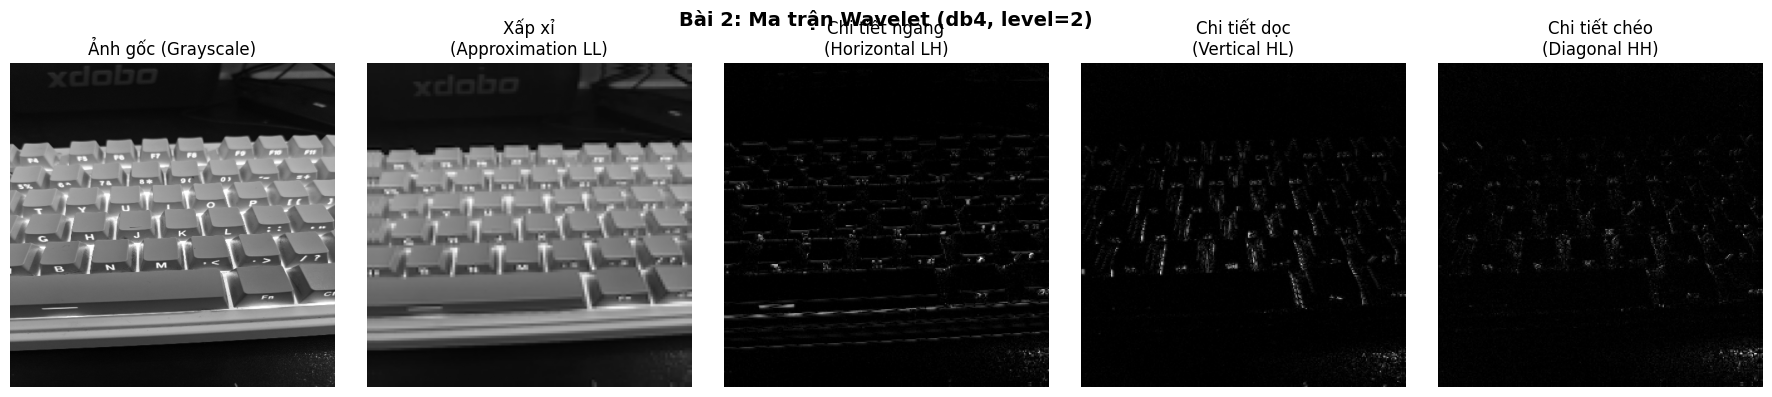

Kích thước ảnh gốc: (512, 512)
Kích thước xấp xỉ (LL): (133, 133)
Kích thước chi tiết mức 1: (259, 259)


In [20]:
def load_and_preprocess(image_path, size=(512, 512)):
    """
    Bài 2: Tải và tiền xử lý hình ảnh
    - Đọc ảnh, chuyển về grayscale và resize về kích thước chuẩn
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f'Không thể đọc ảnh: {image_path}')
    img = cv2.resize(img, size)
    return img.astype(np.float64)

def extract_wavelet_matrix(image_array, wavelet='db4', level=1):
    """
    Bài 2: Trích xuất ma trận wavelet từ ảnh
    - Thực hiện biến đổi wavelet 2D (2D DWT)
    - Trả về danh sách các ma trận hệ số wavelet
    """
    # Biến đổi wavelet 2D nhiều mức (Multi-level 2D DWT)
    coeffs = pywt.wavedec2(image_array, wavelet=wavelet, level=level)
    return coeffs

# Đường dẫn ảnh
input_dir = '../input' if os.path.exists('../input') else './input'
image_paths = [
    os.path.join(input_dir, 'lab_image1.jpg'),
    os.path.join(input_dir, 'lab_image3.jpg'),
]

# Hiển thị hình ảnh gốc và ma trận wavelet
sample_path = image_paths[0]
img_array = load_and_preprocess(sample_path)
coeffs = extract_wavelet_matrix(img_array, wavelet='db4', level=2)

# Lấy xấp xỉ (LL sub-band) và các chi tiết ở mức 1
cA2 = coeffs[0]          # Approximation mức 2
cH1, cV1, cD1 = coeffs[2]  # Detail mức 1: Horizontal, Vertical, Diagonal

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

axes[0].imshow(img_array, cmap='gray')
axes[0].set_title('Ảnh gốc (Grayscale)')
axes[0].axis('off')

axes[1].imshow(cA2, cmap='gray')
axes[1].set_title('Xấp xỉ\n(Approximation LL)')
axes[1].axis('off')

axes[2].imshow(np.abs(cH1), cmap='gray')
axes[2].set_title('Chi tiết ngang\n(Horizontal LH)')
axes[2].axis('off')

axes[3].imshow(np.abs(cV1), cmap='gray')
axes[3].set_title('Chi tiết dọc\n(Vertical HL)')
axes[3].axis('off')

axes[4].imshow(np.abs(cD1), cmap='gray')
axes[4].set_title('Chi tiết chéo\n(Diagonal HH)')
axes[4].axis('off')

plt.suptitle('Bài 2: Ma trận Wavelet (db4, level=2)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Kích thước ảnh gốc: {img_array.shape}')
print(f'Kích thước xấp xỉ (LL): {cA2.shape}')
print(f'Kích thước chi tiết mức 1: {cH1.shape}')

---
## Bài 3: Tạo mã băm (Wavelet Hash)
Tạo mã băm cho mỗi hình ảnh dựa trên các wavelet đã lượng tử hóa.

Bài 3: Mã băm Wavelet
Ảnh 1 - Hash (64 bit): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]...
Ảnh 2 - Hash (64 bit): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]...


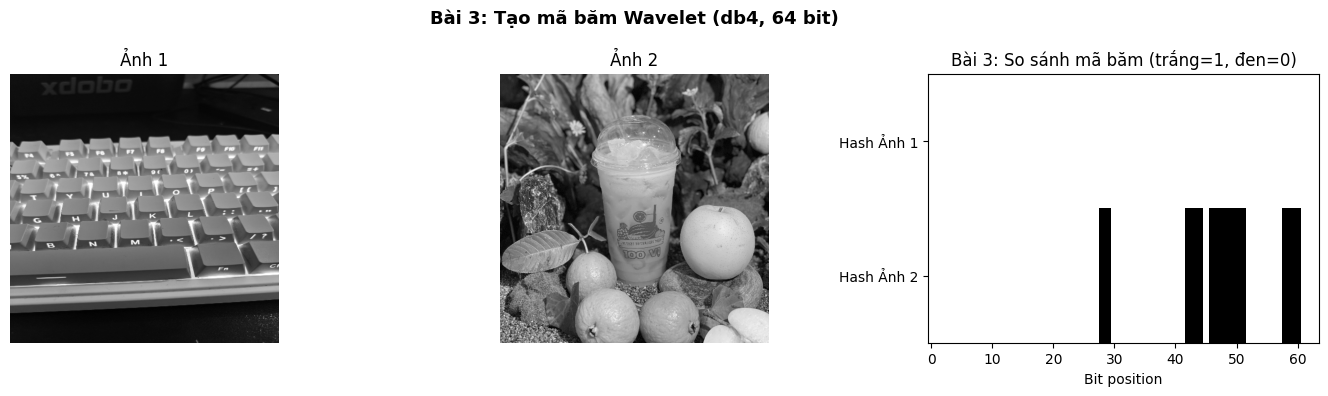

In [21]:
def quantize(arr, bits=2):
    """Hàm lượng tử hóa thủ công thay thế vì thư viện không có pywt.quantize"""
    if isinstance(arr, tuple):
        return tuple(quantize(x, bits) for x in arr)
    arrmin, arrmax = np.min(arr), np.max(arr)
    if arrmin == arrmax: return np.zeros_like(arr, dtype=int)
    return np.round((arr - arrmin) / (arrmax - arrmin) * (bits - 1)).astype(int)

def quantize_coefficients(coeffs, bits=2):
    """
    Bài 3: Lượng tử hóa các hệ số wavelet
    - Giảm độ chính xác của các hệ số
    - bits: số lượng mức lượng tử
    """
    quantized = [quantize(c, bits) for c in coeffs]
    return quantized

def wavelet_hash(image_path, wavelet='db4', level=1, bits=8):
    """
    Bài 3: Tạo mã băm wavelet cho một ảnh
    
    Args:
        image_path: Đường dẫn đến file ảnh
        wavelet: Loại wavelet sử dụng (mặc định 'db4')
        level: Mức phân tích wavelet (mặc định 1)
        bits: Số bit cho mã băm (mặc định 8)
    
    Returns:
        hash_code: Danh sách các bit (0 hoặc 1) đại diện cho mã băm
    """
    # Bước 1: Tải và tiền xử lý ảnh
    img_array = load_and_preprocess(image_path)
    
    # Bước 2: Biến đổi wavelet
    coeffs = pywt.wavedec2(img_array, wavelet=wavelet, level=level)
    
    # Bước 3: Lượng tử hóa các hệ số
    quantized = [quantize(c, 2) for c in coeffs]
    
    # Bước 4: Làm phẳng các hệ số lượng tử đã được làm phẳng
    flattened = np.concatenate([c.flatten() if isinstance(c, np.ndarray)
                                 else np.concatenate([x.flatten() for x in c])
                                 for c in quantized])
    
    # Bước 5: Tạo mã băm (lấy bits đầu tiên, mỗi bit = giá trị % 2)
    hash_code = [int(bit % 2) for bit in flattened[:bits]]
    
    return hash_code

# Test với 2 ảnh mẫu
hash1 = wavelet_hash(image_paths[0], wavelet='db4', level=1, bits=64)
hash2 = wavelet_hash(image_paths[1], wavelet='db4', level=1, bits=64)

print('Bài 3: Mã băm Wavelet')
print(f'Ảnh 1 - Hash ({len(hash1)} bit): {hash1[:20]}...')
print(f'Ảnh 2 - Hash ({len(hash2)} bit): {hash2[:20]}...')

# Trực quan hóa mã băm
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Hiển thị ảnh gốc
img1 = load_and_preprocess(image_paths[0])
img2 = load_and_preprocess(image_paths[1])

axes[0].imshow(img1, cmap='gray')
axes[0].set_title('Ảnh 1')
axes[0].axis('off')

axes[1].imshow(img2, cmap='gray')
axes[1].set_title('Ảnh 2')
axes[1].axis('off')

# Hiển thị bảng so sánh mã băm
hash_matrix = np.array([hash1, hash2])
axes[2].imshow(hash_matrix, cmap='binary', aspect='auto')
axes[2].set_yticks([0, 1])
axes[2].set_yticklabels(['Hash Ảnh 1', 'Hash Ảnh 2'])
axes[2].set_xlabel('Bit position')
axes[2].set_title('Bài 3: So sánh mã băm (trắng=1, đen=0)')

plt.suptitle('Bài 3: Tạo mã băm Wavelet (db4, 64 bit)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Bài 4: So sánh hàm băm (Hamming Distance)
Tính khoảng cách Hamming giữa các mã băm để đánh giá mức độ tương thích giữa các hình ảnh.

Bài 4: Khoảng cách Hamming giữa các cặp ảnh
image1 vs image2:
  Khoảng cách Hamming: 14/64 bit
  Khoảng cách chuẩn hóa: 0.2188
  Tương đồng: 78.1%



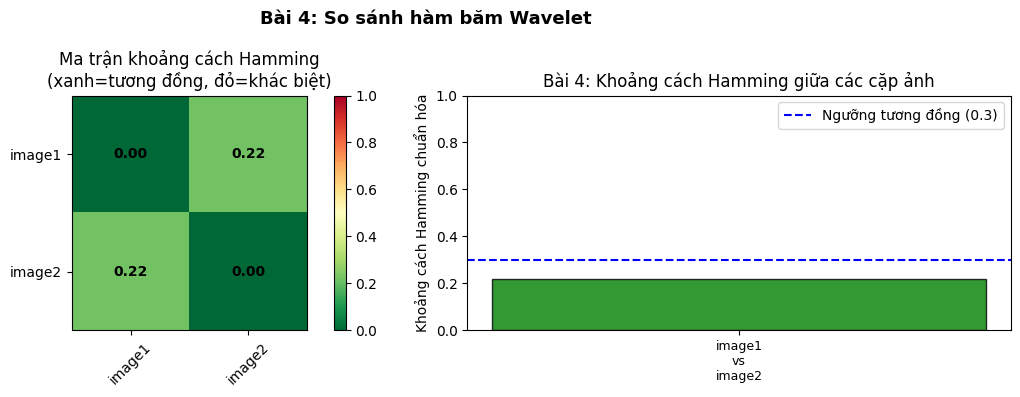

In [22]:
def hamming_distance(hash1, hash2):
    """
    Bài 4: Tính khoảng cách Hamming giữa 2 mã băm
    Khoảng cách Hamming = số bit khác nhau giữa 2 hash
    """
    if len(hash1) != len(hash2):
        raise ValueError('Hai mã băm phải có cùng độ dài!')
    return sum(a != b for a, b in zip(hash1, hash2))

def normalized_hamming_distance(hash1, hash2):
    """Khoảng cách Hamming chuẩn hóa về [0, 1]"""
    return hamming_distance(hash1, hash2) / len(hash1)

# Tạo tập ảnh mẫu để so sánh
# Dùng 2 ảnh có sẵn và tạo thêm biến thể
images_info = [
    {'path': image_paths[0], 'label': 'image1'},
    {'path': image_paths[1], 'label': 'image2'},
]

# Tạo hashes
HASH_BITS = 64
hashes = [wavelet_hash(info['path'], wavelet='db4', level=1, bits=HASH_BITS)
          for info in images_info]
labels = [info['label'] for info in images_info]

# Tính khoảng cách Hamming giữa tất cả các cặp ảnh
print('Bài 4: Khoảng cách Hamming giữa các cặp ảnh')
print('=' * 60)

distances = []
pairs = []

for i in range(len(hashes)):
    for j in range(i + 1, len(hashes)):
        dist = hamming_distance(hashes[i], hashes[j])
        norm_dist = normalized_hamming_distance(hashes[i], hashes[j])
        distances.append((i, j, dist, norm_dist))
        pairs.append((labels[i], labels[j]))
        print(f'{labels[i]} vs {labels[j]}:')
        print(f'  Khoảng cách Hamming: {dist}/{HASH_BITS} bit')
        print(f'  Khoảng cách chuẩn hóa: {norm_dist:.4f}')
        print(f'  Tương đồng: {(1 - norm_dist)*100:.1f}%')
        print()

# Trực quan hóa khoảng cách Hamming
if len(hashes) >= 2:
    n = len(hashes)
    dist_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            dist_matrix[i, j] = normalized_hamming_distance(hashes[i], hashes[j])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Ma trận khoảng cách
    im = axes[0].imshow(dist_matrix, cmap='RdYlGn_r', vmin=0, vmax=1)
    axes[0].set_xticks(range(n))
    axes[0].set_yticks(range(n))
    axes[0].set_xticklabels(labels, rotation=45)
    axes[0].set_yticklabels(labels)
    axes[0].set_title('Ma trận khoảng cách Hamming\n(xanh=tương đồng, đỏ=khác biệt)')
    plt.colorbar(im, ax=axes[0])

    # Hiển thị giá trị trong ma trận
    for i in range(n):
        for j in range(n):
            axes[0].text(j, i, f'{dist_matrix[i,j]:.2f}',
                        ha='center', va='center', fontsize=10, fontweight='bold')

    # Biểu đồ cột khoảng cách
    pair_labels = [f'{p[0]}\nvs\n{p[1]}' for p in pairs]
    dist_values = [d[3] for d in distances]
    colors = ['green' if d < 0.3 else 'orange' if d < 0.5 else 'red' for d in dist_values]
    axes[1].bar(range(len(dist_values)), dist_values, color=colors, alpha=0.8, edgecolor='black')
    axes[1].set_xticks(range(len(dist_values)))
    axes[1].set_xticklabels(pair_labels, fontsize=9)
    axes[1].set_ylabel('Khoảng cách Hamming chuẩn hóa')
    axes[1].set_ylim(0, 1)
    axes[1].axhline(y=0.3, color='blue', linestyle='--', label='Ngưỡng tương đồng (0.3)')
    axes[1].legend()
    axes[1].set_title('Bài 4: Khoảng cách Hamming giữa các cặp ảnh')

    plt.suptitle('Bài 4: So sánh hàm băm Wavelet', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## Bài 5: Đánh giá
Tính các chỉ số: **Độ chính xác (Accuracy)**, **Độ nhạy (Recall)**, **Độ đặc biệt (Precision)**, và vẽ **Đường cong ROC**.

Bài 5: Đánh giá kết quả
Ngưỡng phân loại: 0.35
TP=5, TN=5, FP=0, FN=0
Độ chính xác (Accuracy):  1.0000 (100.0%)
Độ nhạy     (Recall):     1.0000 (100.0%)
Độ đặc biệt (Precision):  1.0000 (100.0%)
F1-Score:                 1.0000


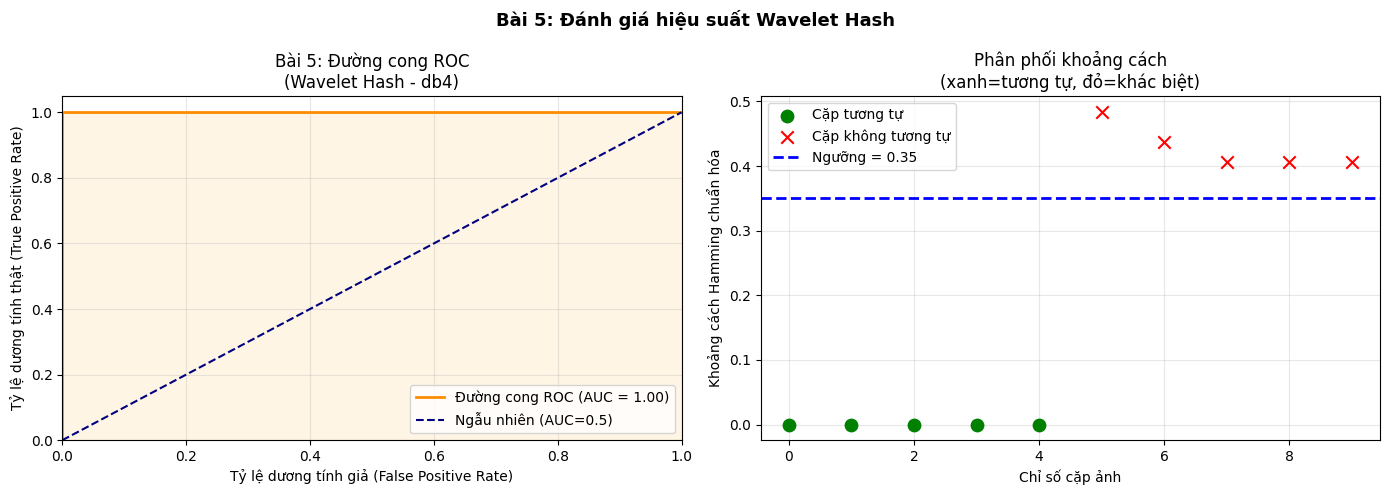


Kết quả cuối cùng:
  Độ chính xác (Accuracy):  100.00%
  Độ nhạy     (Recall):     100.00%
  Độ đặc biệt (Precision):  100.00%
  AUC (ROC):                1.0000


In [23]:
import numpy as np
import cv2
import io

def create_similar_image(image_path, noise_level=10):
    """Tạo ảnh tương tự bằng cách thêm nhiễu nhẹ"""
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: raise ValueError(f'Không thể đọc: {image_path}')
    img = cv2.resize(img, (512, 512))
    img_array = img.astype(np.float64)
    # Thêm nhiễu Gaussian nhẹ
    noise = np.random.normal(0, noise_level, img_array.shape)
    noisy = np.clip(img_array + noise, 0, 255).astype(np.uint8)
    return noisy

def create_different_image(size=(512, 512)):
    """Tạo ảnh hoàn toàn ngẫu nhiên (không tương tự)"""
    return np.random.randint(0, 256, size, dtype=np.uint8)

# Tạo tập đánh giá:
# - Cặp TƯƠNG TỰ: ảnh gốc và ảnh có nhiễu nhẹ (ground truth = 1)
# - Cặp KHÔNG TƯƠNG TỰ: ảnh gốc và ảnh ngẫu nhiên (ground truth = 0)

import tempfile

eval_hashes = []
eval_labels = []  # 1 = tương tự, 0 = không tương tự
eval_pairs = []

BASE_BITS = 64

# Tạo hash ảnh gốc
hash_orig = wavelet_hash(image_paths[0], bits=BASE_BITS)

# Tạo 5 cặp TƯƠNG TỰ (nhiễu mức thấp)
for noise in [5, 10, 15, 20, 25]:
    similar_img = create_similar_image(image_paths[0], noise_level=noise)
    tmp_name = "tmp_eval_image.png"
    cv2.imwrite(tmp_name, similar_img)
    h = wavelet_hash(tmp_name, bits=BASE_BITS)
    if os.path.exists(tmp_name): os.remove(tmp_name)
    eval_hashes.append((hash_orig, h))
    eval_labels.append(1)  # Tương tự
    eval_pairs.append(f'Tương tự (noise={noise})')

# Tạo 5 cặp KHÔNG TƯƠNG TỰ (ảnh ngẫu nhiên)
for i in range(5):
    diff_img = create_different_image()
    tmp_name = "tmp_eval_image.png"
    cv2.imwrite(tmp_name, diff_img)
    h = wavelet_hash(tmp_name, bits=BASE_BITS)
    if os.path.exists(tmp_name): os.remove(tmp_name)
    eval_hashes.append((hash_orig, h))
    eval_labels.append(0)  # Không tương tự
    eval_pairs.append(f'Không tương tự (rand {i+1})')

# Tính khoảng cách Hamming cho từng cặp
norm_distances = [normalized_hamming_distance(h1, h2) for h1, h2 in eval_hashes]

# Ngưỡng phân loại: nếu khoảng cách < threshold => tương tự
THRESHOLD = 0.35
predictions = [1 if d < THRESHOLD else 0 for d in norm_distances]

# Tính các chỉ số đánh giá
ground_truth = eval_labels
gt = np.array(ground_truth)
pred = np.array(predictions)

TP = np.sum((gt == 1) & (pred == 1))  # Tương tự và dự đoán đúng
TN = np.sum((gt == 0) & (pred == 0))  # Không tương tự và dự đoán đúng
FP = np.sum((gt == 0) & (pred == 1))  # Không tương tự nhưng dự đoán là tương tự
FN = np.sum((gt == 1) & (pred == 0))  # Tương tự nhưng dự đoán là không tương tự

accuracy  = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0  # Độ nhạy
precision = TP / (TP + FP) if (TP + FP) > 0 else 0  # Độ đặc biệt
f1_score  = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print('Bài 5: Đánh giá kết quả')
print('=' * 50)
print(f'Ngưỡng phân loại: {THRESHOLD}')
print(f'TP={TP}, TN={TN}, FP={FP}, FN={FN}')
print(f'Độ chính xác (Accuracy):  {accuracy:.4f} ({accuracy*100:.1f}%)')
print(f'Độ nhạy     (Recall):     {recall:.4f} ({recall*100:.1f}%)')
print(f'Độ đặc biệt (Precision):  {precision:.4f} ({precision*100:.1f}%)')
print(f'F1-Score:                 {f1_score:.4f}')

# Vẽ đường cong ROC
# Điểm số cho ROC: dùng (1 - normalized_distance) làm xác suất dự đoán
scores = [1 - d for d in norm_distances]

fpr, tpr, thresholds = roc_curve(ground_truth, scores)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Đường cong ROC
axes[0].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Đường cong ROC (AUC = {roc_auc:.2f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Ngẫu nhiên (AUC=0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='orange')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('Tỷ lệ dương tính giả (False Positive Rate)')
axes[0].set_ylabel('Tỷ lệ dương tính thật (True Positive Rate)')
axes[0].set_title('Bài 5: Đường cong ROC\n(Wavelet Hash - db4)')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Biểu đồ phân phối khoảng cách
similar_dists = [d for d, l in zip(norm_distances, ground_truth) if l == 1]
diff_dists    = [d for d, l in zip(norm_distances, ground_truth) if l == 0]

axes[1].scatter(range(len(similar_dists)), similar_dists, color='green',
                label='Cặp tương tự', s=80, marker='o', zorder=5)
axes[1].scatter(range(len(similar_dists), len(similar_dists) + len(diff_dists)),
                diff_dists, color='red', label='Cặp không tương tự', s=80, marker='x', zorder=5)
axes[1].axhline(y=THRESHOLD, color='blue', linestyle='--', linewidth=2,
                label=f'Ngưỡng = {THRESHOLD}')
axes[1].set_xlabel('Chỉ số cặp ảnh')
axes[1].set_ylabel('Khoảng cách Hamming chuẩn hóa')
axes[1].set_title('Phân phối khoảng cách\n(xanh=tương tự, đỏ=khác biệt)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Bài 5: Đánh giá hiệu suất Wavelet Hash', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nKết quả cuối cùng:')
print(f'  Độ chính xác (Accuracy):  {accuracy:.2%}')
print(f'  Độ nhạy     (Recall):     {recall:.2%}')
print(f'  Độ đặc biệt (Precision):  {precision:.2%}')
print(f'  AUC (ROC):                {roc_auc:.4f}')